# CNN Image Classification on CIFAR-10
Hands-on experiment: CNN building blocks, hyperparameters, feature maps, pooling comparison, and model evaluation using TensorFlow/Keras.

In [28]:
import matplotlib.pyplot as plt

# To install the font library required for specific fonts
!wget -q -O /content/TimesNewRoman.ttf https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf
!wget -q -O /content/times.ttf https://github.com/FSKiller/Microsoft-Fonts/raw/main/times.ttf
!wget -q -O /content/timesbd.ttf https://github.com/FSKiller/Microsoft-Fonts/raw/main/timesbd.ttf

import matplotlib.font_manager as fm

fm.fontManager.addfont('/content/TimesNewRoman.ttf')
fm.fontManager.addfont('/content/times.ttf')
fm.fontManager.addfont('/content/timesbd.ttf')

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

## 1. Import Libraries

In [29]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


## 2. Load the CIFAR-10 Dataset

In [30]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer','dog', 'frog', 'horse', 'ship', 'truck']

y_train = y_train.flatten()
y_test = y_test.flatten()

print("Train shape:", x_train.shape, y_train.shape)
print("Test shape :", x_test.shape, y_test.shape)


Train shape: (50000, 32, 32, 3) (50000,)
Test shape : (10000, 32, 32, 3) (10000,)


## 3. Explore the Data: Class Distribution & Sample Images

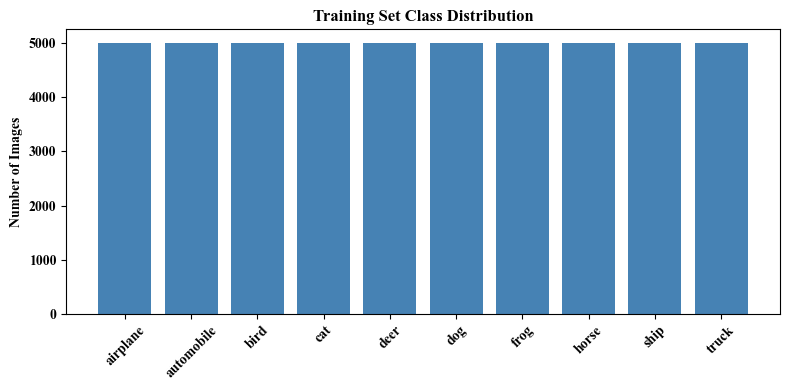

In [31]:
# Class distribution
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 4))
plt.bar([class_names[i] for i in unique], counts, color='steelblue')
plt.title("Training Set Class Distribution")
plt.xticks(rotation=45)
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()


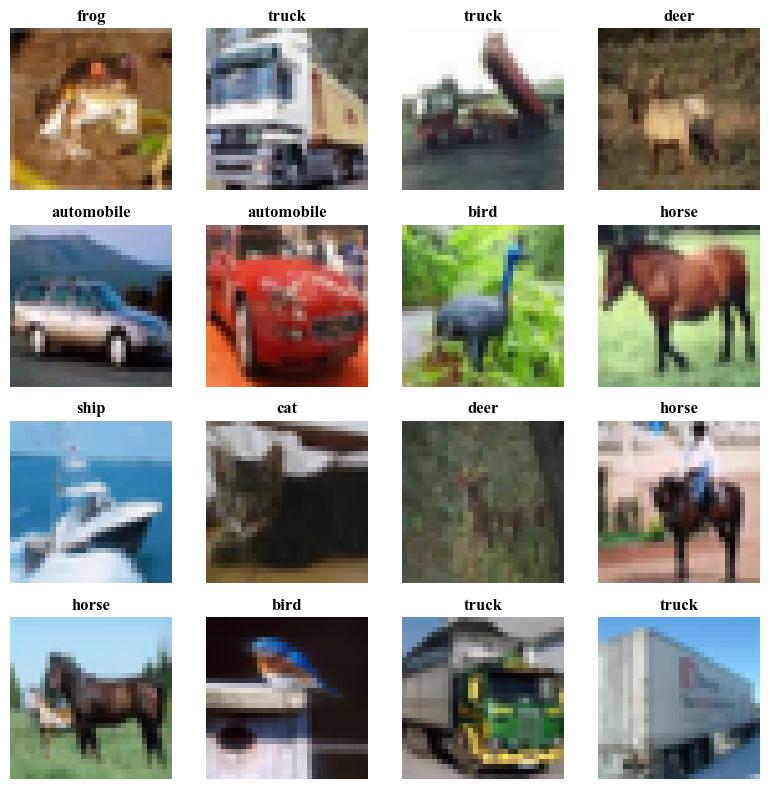

In [32]:
# Sample images
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()


## 4. Preprocess the Data
Normalize pixel values to [0, 1] and one-hot encode the labels.

In [33]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("x_train range:", x_train.min(), "-", x_train.max())
print("y_train sample:", y_train[:5])



x_train range: 0.0 - 1.0
y_train sample: [6 9 9 4 1]


## 5. Build the CNN Architecture
Building blocks: Conv2D (feature extraction) -> ReLU (activation) -> MaxPooling2D (downsampling) -> Flatten -> Dense (classification).

Key hyperparameters shown here: **kernel size**, **number of filters**, **stride**, and **padding**.

In [34]:
def build_cnn(kernel_size=(3, 3), padding='valid', pool_type='max'):
    PoolLayer = layers.MaxPooling2D if pool_type == 'max' else layers.AveragePooling2D

    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, kernel_size, strides=(1, 1), padding=padding, activation='relu'),
        PoolLayer(pool_size=(2, 2)),

        layers.Conv2D(64, kernel_size, strides=(1, 1), padding=padding, activation='relu'),
        PoolLayer(pool_size=(2, 2)),

        layers.Conv2D(64, kernel_size, strides=(1, 1), padding=padding, activation='relu'),

        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10)
    ])
    return model

model = build_cnn()
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Analyze Trainable Parameters per Layer
For a Conv2D layer: `params = (kernel_h * kernel_w * in_channels + 1) * num_filters`.

In [35]:
for layer in model.layers:
    if layer.count_params() > 0:
        print(f"{layer.name:15s} | output shape: {str(layer.output.shape):20s} | "
              f"params: {layer.count_params()}")


conv2d_9        | output shape: (None, 30, 30, 32)   | params: 896
conv2d_10       | output shape: (None, 13, 13, 64)   | params: 18496
conv2d_11       | output shape: (None, 4, 4, 64)     | params: 36928
dense_6         | output shape: (None, 64)           | params: 65600
dense_7         | output shape: (None, 10)           | params: 650


## 7. Compile and Train the Model
Hyperparameters explored here: **optimizer**, **batch size**, and **epochs**.

In [36]:
optimizer = 'adam'
batch_size = 64
epochs = 15

model.compile(optimizer=optimizer,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
                     validation_split=0.1,
                     batch_size=batch_size,
                     epochs=epochs,
                     verbose=1)



Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 44ms/step - accuracy: 0.4085 - loss: 1.6184 - val_accuracy: 0.5034 - val_loss: 1.3911
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.5533 - loss: 1.2522 - val_accuracy: 0.5802 - val_loss: 1.1768
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.6153 - loss: 1.0916 - val_accuracy: 0.5978 - val_loss: 1.1429
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.6451 - loss: 1.0053 - val_accuracy: 0.6530 - val_loss: 0.9855
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - accuracy: 0.6783 - loss: 0.9237 - val_accuracy: 0.6628 - val_loss: 0.9976
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 44ms/step - accuracy: 0.6988 - loss: 0.8630 - val_accuracy: 0.6946 - val_loss: 0.8924
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.7202 - loss: 0.8022 - val_accuracy: 0.6878 - val_loss: 0.9068
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.7327 - loss: 0.7607 - 

## 8. Training & Validation Accuracy / Loss Curves

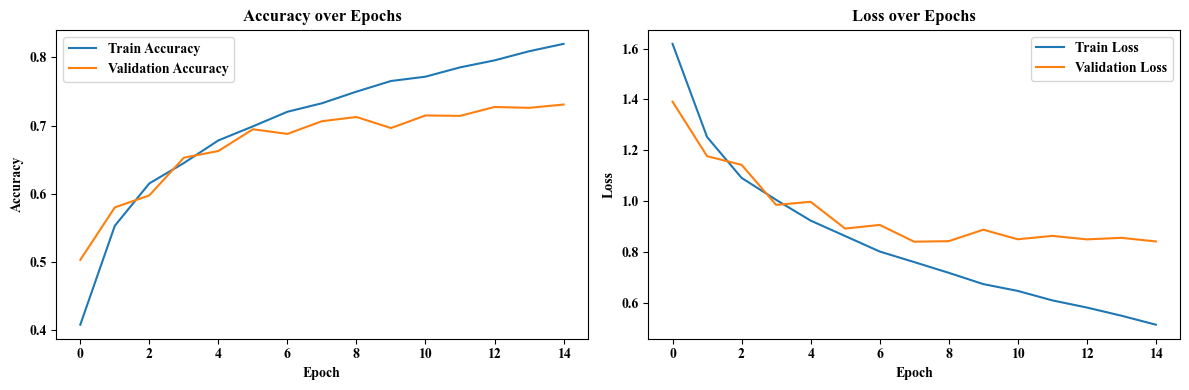

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


## 9. Evaluate the Model
Metrics: accuracy, precision, recall, F1-score, confusion matrix, classification report.

In [38]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss    : {test_loss:.4f}")

y_pred_logits = model.predict(x_test)
y_pred = np.argmax(y_pred_logits, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))



Test Accuracy: 0.7129
Test Loss    : 0.9034
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

Classification Report:

              precision    recall  f1-score   support

    airplane       0.78      0.71      0.74      1000
  automobile       0.87      0.78      0.83      1000
        bird       0.62      0.57      0.60      1000
         cat       0.54      0.53      0.54      1000
        deer       0.68      0.65      0.67      1000
         dog       0.59      0.63      0.61      1000
        frog       0.78      0.80      0.79      1000
       horse       0.74      0.77      0.75      1000
        ship       0.78      0.84      0.81      1000
       truck       0.75      0.85      0.79      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000



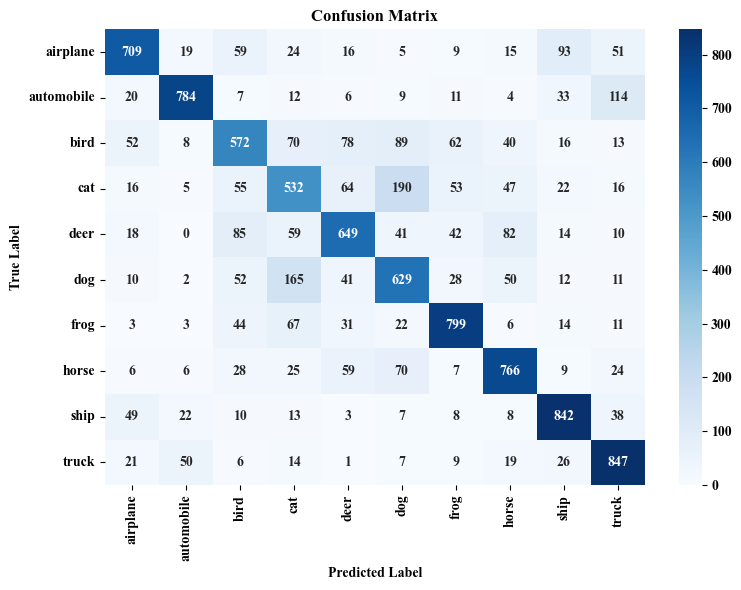

In [39]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()



## 10. Visualize Intermediate Feature Maps
See how convolutional layers progressively extract hierarchical features (edges, textures, patterns) from an input image.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


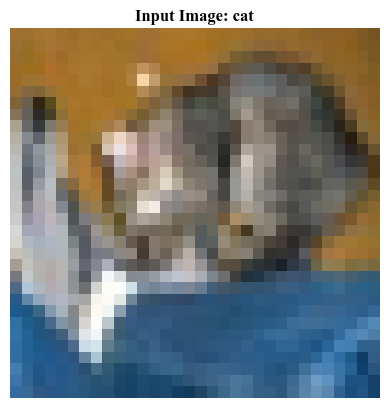

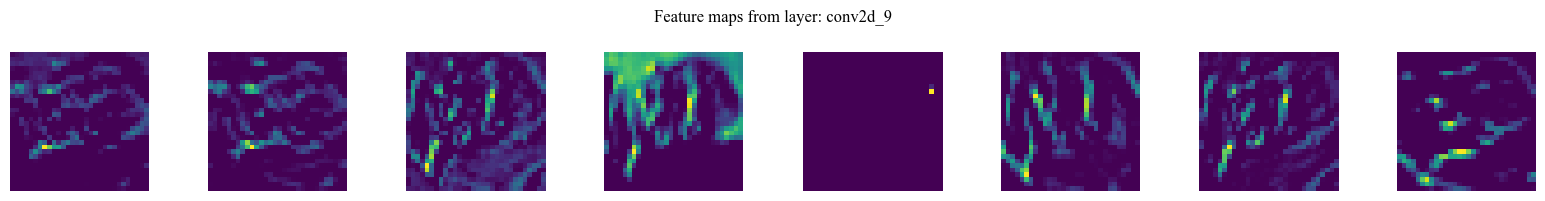

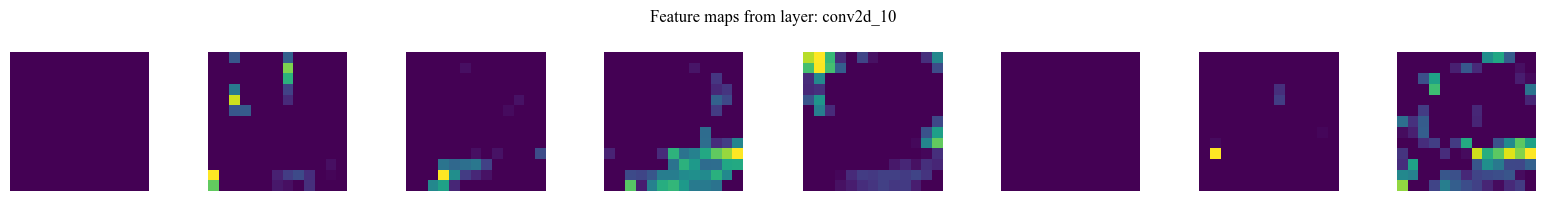

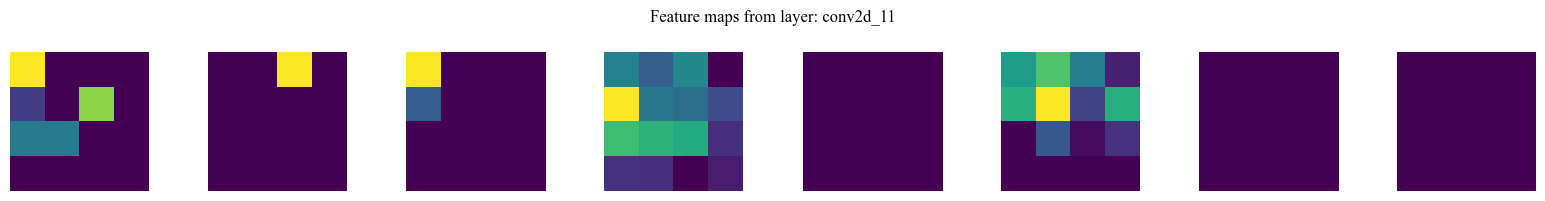

In [40]:
conv_layer_names = [l.name for l in model.layers if isinstance(l, layers.Conv2D)]
outputs = [model.get_layer(name).output for name in conv_layer_names]
feature_map_model = models.Model(inputs=model.inputs, outputs=outputs)

sample_img = x_test[0:1]
feature_maps = feature_map_model.predict(sample_img)

plt.imshow(x_test[0])
plt.title(f"Input Image: {class_names[y_test[0]]}")
plt.axis('off')
plt.show()

for layer_name, fmap in zip(conv_layer_names, feature_maps):
    n_filters = min(8, fmap.shape[-1])
    plt.figure(figsize=(16, 2))
    plt.suptitle(f"Feature maps from layer: {layer_name}")
    for i in range(n_filters):
        plt.subplot(1, n_filters, i + 1)
        plt.imshow(fmap[0, :, :, i], cmap='viridis')
        plt.axis('off')
    plt.tight_layout()
    plt.show()


## 11. Compare Pooling Strategies: Max Pooling vs Average Pooling
Train a second, identical model that uses Average Pooling instead of Max Pooling, and compare final test accuracy.

Test Accuracy (Max Pooling)    : 0.7129
Test Accuracy (Average Pooling): 0.7054


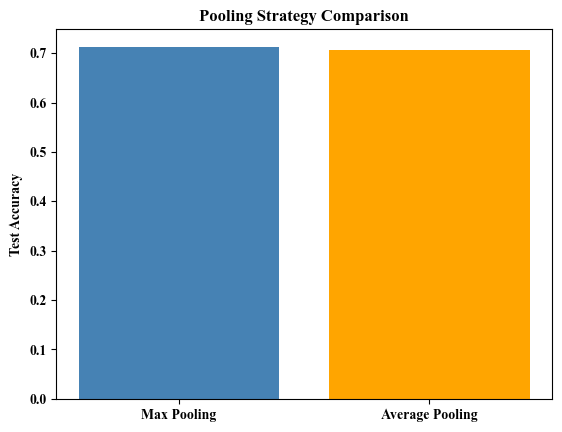

In [41]:
model_avg = build_cnn(pool_type='average')
model_avg.compile(optimizer='adam',
                   loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                   metrics=['accuracy'])

history_avg = model_avg.fit(x_train, y_train,
                             validation_split=0.1,
                             batch_size=64,
                             epochs=15,
                             verbose=0)

_, acc_max = model.evaluate(x_test, y_test, verbose=0)
_, acc_avg = model_avg.evaluate(x_test, y_test, verbose=0)

print(f"Test Accuracy (Max Pooling)    : {acc_max:.4f}")
print(f"Test Accuracy (Average Pooling): {acc_avg:.4f}")

plt.bar(['Max Pooling', 'Average Pooling'], [acc_max, acc_avg], color=['steelblue', 'orange'])
plt.ylabel('Test Accuracy')
plt.title('Pooling Strategy Comparison')
plt.show()

## 12. Quick Hyperparameter Experiment: Kernel Size
Train small models with different kernel sizes for a few epochs to observe the effect on accuracy and parameter count.

In [43]:
kernel_sizes = [(3, 3), (5, 5)]
results = {}

for k in kernel_sizes:
    m = build_cnn(kernel_size=k)
    m.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
    h = m.fit(x_train, y_train, validation_split=0.1,
              batch_size=64, epochs=5, verbose=0)
    _, acc = m.evaluate(x_test, y_test, verbose=0)
    results[str(k)] = {'test_acc': acc, 'params': m.count_params()}

for k, v in results.items():
    print(f"Kernel size {k}: Test Accuracy = {v['test_acc']:.4f}, "
          f"Total Params = {v['params']}")



Kernel size (3, 3): Test Accuracy = 0.6586, Total Params = 122570
Kernel size (5, 5): Test Accuracy = 0.6602, Total Params = 160970


## Conclusion
This notebook covered: CNN building blocks (convolution, activation, pooling, flatten, dense), the effect of key hyperparameters (kernel size, stride, padding, filters, optimizer, batch size, epochs), feature map visualization, pooling strategy comparison, trainable parameter analysis, and full model evaluation (accuracy, precision, recall, F1-score, confusion matrix) on CIFAR-10.